# COGS 108 - Final Project (change this to your project's title)

# Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public. (Note that student names will be included (but PIDs will be scraped from any groups who include their PIDs).

* [ X ] YES - make available
* [  ] NO - keep private

# Names

- Vaibhav Bommisetty
- Daniel Erskine
- Angie Nguyen
- Jett Ou
- Dan Van

# Abstract

For our project, we are analyzing datasets of movie ratings to determine which movie in a trilogy has the best overall performance. We chose this topic because it was a fun and interesting way to present the skills we have gained during COGS108. Through our data wrangling, analysis and visualization, we proved our hypothesis wrong with the first movie has the best performance in most trilogies by our metric.

# Research Question

Consider the list of all movie trilogies ever made, which installment in the trilogy performs the best? To measure performance, we’re considering training a model so that it can classify which installment an arbitrary movie in a trilogy is. We will train this model revenue compared with budget in dollars and voting metrics. 

## Background and Prior Work

Our topic will explore which movie installment tends to be the best in a trilogy of movies: the first, second, or third movie. There are numerous examples of each. *The Matrix* is considered to be the best in The Matrix trilogy, while *The Dark Knight*, which is the second movie in the franchise, is often referred to as the best of the Christopher Nolan Batman trilogy. Lastly, *The Return of the King* won the most academy awards and had the largest box office of the Lord of the Rings trilogy despite being the last film in the trilogy. We don’t have much prior knowledge on this topic besides anecdotal evidence of movies in trilogies we have seen, conversations with friends and family about movies, or reading/watching reviews of movies. There are various ways you can rate the success of a movie, examples being audience reviews, critic reviews, box office numbers, or number of academy awards won so we will compare and contrast many variables. 

There is very little prior knowledge or research on this topic. There are no scientific studies or research papers even remotely related to the topic. We were surprised by the amount of studies on the Lord of the Rings trilogy: when looking up “Movie trilogy” in google scholar, five out of the first eight articles were related to the Lord of the Rings trilogy. While there isn’t any research based in science on this topic, there are numerous articles and blogs dedicated to topics very similar to our research question. Business Insider made a video “Why the third film in a trilogy is almost always the worst” (1) which determined that on average, the third film in a trilogy has the lowest rotten tomatoes score and makes the least amount of money in the box office compared to the previous two installments in a given film trilogy. Exa Zim and Nathaniel Lee discuss how these films continue to be made despite performing worse than their predecessors because they are still making huge amounts of money. Third installments tend to have the largest budget of any movie in a trilogy, as seen with The Dark Knight trilogy. Matt Singer of Screen Crush wrote an article “The Best Third Films in Movie Trilogies” (2) which explores which third movies are the highest quality, not which third movies are the best in their respective trilogy. For example, *Return of the Jedi* is on the list despite *The Empire Strikes Back* being widely considered to be a better movie. Singer’s list is interesting but doesn’t provide much useful information about each movie. Another reference we found is a blog post on the website Quora by Mark Hughes called “In what movie trilogies can the 2nd movie be considered better than the first?” (3). Hughes lists out second movies that he believes are better than first movies. It is important to note that not all of his picks are the “consensus” best movie in the franchise: for example, he states that *Blade II* is better than *Blade* despite *Blade* having higher IMDB scores, Rotten Tomatoes audience scores, and critic scores. To conclude, there is very little prior work on the topic of which movie tends to be the best in a film trilogy.

1. <a name="cite_note-1"></a> [^](#cite_ref-1) Zim and Lee. (6 May 2020) Why the third film in a trilogy is almost always the worst. *Business Insider*. https://www.businessinsider.com/why-the-third-film-in-a-trilogy-almost-always-sucks-2020-5 
2. <a name="cite_note-2"></a> [^](#cite_ref-2) Singer, M. (14 April 2022) The Best Third Films In Movie Trilogies. *Screen Crush*. https://screencrush.com/best-third-films-in-movie-trilogies/
3. <a name="cite_note-3"></a> [^](#cite_ref-3) Hughes M. (10 Feb 2012) In What movie trilogies can the 2nd movie be considered better than the first? *Quora*. https://www.quora.com/In-what-movie-trilogies-can-the-2nd-movie-be-considered-better-than-the-first 


# Hypothesis



The last movie performs the best in trilogies.

We will count performance as a range of factors: awards such as the Golden Globes and Academy Awards, box office revenue, and ratings from websites such as IMDb and Rotten Tomatoes. We say that the last movie will perform the best as it usually has the greatest amount of anticipation, and can rely on the exposure that the first two movies were able to build.

# Data

## Data overview

For each dataset include the following information
- Dataset #1
  - Dataset Name: movies_metadata.csv from The Movies Dataset
  - Link to the dataset: https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset
  - Number of observations: 45466
  - Number of variables: 24
- Dataset #2
  - Dataset Name: links.csv from The Movies Dataset
  - Link to the dataset: https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset
  - Number of observations: 86537
  - Number of variables: 3
- Dataset #3
  - Dataset Name: ratings.csv from MovieLens Dataset
  - Link to the dataset: https://grouplens.org/datasets/movielens/latest/
  - Number of observations: 33832162
  - Number of variables: 4

Dataset #1 is the big dataset we're using, last updated in July 2017. Each observation is one movie and its metrics - name, series, budget, revenue, popularity, etc; we will only be focusing on the metrics aimed to capture performance. Budget/revenue are measured in dollars, which could tell us how well a movie did by the difference or ratio between them. Vote average and vote count are on a scale of 10, which comes from tmdb; we opted to use a more recently updated dataset for ratings. Popularity is a metric that's vaguely described; it's calculated by a model that takes into account several factors like "Number of views for the day", "Number of users who marked it as a 'favourite' for the day", etc., which can be found more about [here](https://developer.themoviedb.org/docs/popularity-and-trending)

Dataset #2 is simply the dataset we use to connect Dataset #1 with Dataset #3. Each observation is one movie, and each variable is its associated ID in The MovieLens Dataset, IMDb, TMDb. 

Dataset #3 is the ratings dataset. Each observation is one review, and each variable is its associated reviewer ID, movie ID, rating, and timestamp. 


## Dataset #1 - The Movies Dataset

Regarding the preprocessing of these datasets, only the first one needed much work. We first drop any movies that aren't in a trilogy, and any movies that have missing data. The former tends to come in the form of 0 budget or 0 revenue, which is rather unrealistic. We considered that we might potentially drop a few indie films that are made. However, our focus is on trilogies, so there tends to be less indie films that fit in that category, and that small amount would likely not make a big difference in the data. Then, we calculated the associated budget/revenue differences.

#### Import pandas, numpy and scipy.

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
import seaborn as sns
from scipy.stats import kruskal

#### Extract the collection name and only include trilogies.

In [2]:
def extract_collection_name(collection_dict):
    try:
        return collection_dict.split('\'')[5]
    except:
        return np.nan

def keep_only_three(group):
    if len(group) == 3:
        return group
    else:
        return pd.DataFrame()

#### Import the data from file.

In [3]:
df = pd.read_csv('data/movies_metadata.csv')

/Users/vaibhavbommisetty/anaconda3/envs/dsc80/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3505: DtypeWarning: Columns (10) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [4]:
df = pd.read_csv('data/movies_metadata.csv')

#### Drop movies that aren't in a series.

In [5]:
df = df.dropna(subset=['belongs_to_collection'])

#### Drop missing/"unrealistic" movies.

In [6]:
df = df[(df['budget'] != 0) & (df['budget'] != '0') & (df['revenue'] != 0) & (df['revenue'] != '0')]

#### Add series column.

In [7]:
df['series'] = df['belongs_to_collection'].apply(extract_collection_name)
df = df.dropna(subset=['series'])

#### Drop movies that aren't in a trilogy.

In [8]:
df = df.sort_values(by='release_date').groupby('series').apply(keep_only_three).reset_index(drop=True)

#### Convert budget to float.

In [9]:
df['budget'] = df['budget'].apply(float)

#### Add budget variance in $ and %.

In [10]:
def get_variance_percentage(row):
    return row['revenue'] / row['budget']

def get_variance_difference(row):
    return row['revenue'] - row['budget']

df['budget_variance%'] = df.apply(get_variance_percentage, axis=1)
df['budget_variance$'] = df.apply(get_variance_difference, axis=1)

#### Reorder the columns.

In [11]:
df = df.filter(['id', 'original_title', 'series', 'budget', 'revenue', 'budget_variance%', 'budget_variance$', 'vote_average', 'vote_count', 'popularity', 'runtime', 'release_date'])
df.head()

,id,original_title,series,budget,revenue,budget_variance%,budget_variance$,vote_average,vote_count,popularity,runtime,release_date
0,9437,Kiss the Girls,Alex Cross Collection,27000000.0,60527873.0,2.241773,33527873.0,6.2,353.0,12.235391,115.0,1997-10-03
1,2043,Along Came a Spider,Alex Cross Collection,60000000.0,105178561.0,1.752976,45178561.0,6.1,408.0,13.214068,104.0,2001-04-06
2,94348,Alex Cross,Alex Cross Collection,45000000.0,30353232.0,0.674516,-14646768.0,5.1,303.0,8.279285,101.0,2012-10-18
3,6477,Alvin and the Chipmunks,Alvin and the Chipmunks Collection,60000000.0,361366633.0,6.022777,301366633.0,5.5,1212.0,11.805233,92.0,2007-12-13
4,23398,Alvin and the Chipmunks: The Squeakquel,Alvin and the Chipmunks Collection,75000000.0,443140005.0,5.908533,368140005.0,5.3,688.0,9.909961,88.0,2009-12-21


## Dataset #2 - Links

#### Import the links from file

In [12]:
links = pd.read_csv('data/links.csv', dtype=str)

## Dataset #3 - Ratings

The final part is to calculate how well the movie performed in terms of votes. Consider the following situation: movie A has 5 votes, and the vote average is 10, while movie B has 1000 votes, and the vote average is 9.5. According to intuition, we'd want say movie B performed better. This intuition is captured by the confidence interval, where a low amount of votes would lead to a wider confidence interval designed to contain the "true" rating of the movie. This comes with the assumption that the votes are normally distributed, and are independent, which could be argued against. We don't know the variance of the distribution, so we opted to use the t-distribution and calculate the confidence interval from there. 

#### Import the ratings from dropbox file

A few things to explain here: github doesn't track files larger than 100mb, so we opted to store it in a dropbox, and load it in from there. norm_ratings does what its name suggests, it just normalizes the ratings to a 10 point scale. getlb, upon given a movie id, will return the corresponding lower bound of the confidence interval generated by the t-distribution.

In [13]:
path = 'https://www.dropbox.com/scl/fi/xri7r33ven576rhxvbjlr/ratings.csv?rlkey=2olbbizsswn4desqi7z55hvrv&dl=1'
ratings = pd.read_csv(path)

def norm_ratings(r):
    return 2 * float(r)

def getlb(s):
    movie = links[links['tmdbId'] == s]['movieId'].unique()[0]
    temp = ratings[ratings['movieId'] == int(movie)][['rating']]
    temp['rating'] = temp['rating'].apply(norm_ratings)
    temp = list(temp['rating'])
    return st.t.interval(0.9, len(temp)-1, loc=np.mean(temp), scale=st.sem(temp))[0]

## Dataset - Combine

#### Find lower bound of confidence interval of rating

In [14]:
df['cf_lb'] = df['id'].apply(getlb)
df.head()

,id,original_title,series,budget,revenue,budget_variance%,budget_variance$,vote_average,vote_count,popularity,runtime,release_date,cf_lb
0,9437,Kiss the Girls,Alex Cross Collection,27000000.0,60527873.0,2.241773,33527873.0,6.2,353.0,12.235391,115.0,1997-10-03,6.715652
1,2043,Along Came a Spider,Alex Cross Collection,60000000.0,105178561.0,1.752976,45178561.0,6.1,408.0,13.214068,104.0,2001-04-06,6.506209
2,94348,Alex Cross,Alex Cross Collection,45000000.0,30353232.0,0.674516,-14646768.0,5.1,303.0,8.279285,101.0,2012-10-18,5.016771
3,6477,Alvin and the Chipmunks,Alvin and the Chipmunks Collection,60000000.0,361366633.0,6.022777,301366633.0,5.5,1212.0,11.805233,92.0,2007-12-13,4.518885
4,23398,Alvin and the Chipmunks: The Squeakquel,Alvin and the Chipmunks Collection,75000000.0,443140005.0,5.908533,368140005.0,5.3,688.0,9.909961,88.0,2009-12-21,3.931392


#### Classify each movie with its corresponding position in the trilogy

In [15]:
def order(n):
    return n%3 + 1

df = df.reset_index()
df['index'] = df['index'].apply(order)
df = df.rename(columns={'index' : 'pos'})

#### Normalizing within each series

Consider the following situation: a small indie trilogy with likely low budget/revenue and ratings, and a big trilogy with very high numbers. We seek to compare movies within each trilogy, not across series. If we don't normalize, it is likely that small trilogies will be classified as bad performing entries, while the movies of big ones will always be considered to be the best performing movies within its trilogy.

#### Normalizing the profit share percentage within each series

In [16]:
def calculate_profit_share(i):
    n = i // 3 * 3
    mov1, mov2, mov3 = df.loc[n]['budget_variance%'], df.loc[n+1]['budget_variance%'], df.loc[n+2]['budget_variance%']
    sum = mov1 + mov2 + mov3
    return df.loc[i]['budget_variance%'] / sum

df = df.reset_index()
df['index'] = df['index'].apply(calculate_profit_share)
df = df.rename(columns={'index': 'profit_share'})

#### Normalizing the ratings share within each series

In [17]:
def calculate_ratings_share(i):
    n = i // 3 * 3
    mov1, mov2, mov3 = df.loc[n]['cf_lb'], df.loc[n+1]['cf_lb'], df.loc[n+2]['cf_lb']
    sum = mov1 + mov2 + mov3
    return df.loc[i]['cf_lb'] / sum

df = df.reset_index()
df['index'] = df['index'].apply(calculate_ratings_share)
df = df.rename(columns={'index': 'ratings_share'})

#### Filtering to the most essential variables

In [18]:
df = df[['profit_share', 'ratings_share', 'pos']]
df.head()

,profit_share,ratings_share,pos
0,0.480113,0.368210,1
1,0.375429,0.356727,2
2,0.144459,0.275063,3
3,0.365004,0.363692,1
4,0.358080,0.316409,2


## Data Visualization

### Profit share percentages

#### Here's the general trend of the profit shares of the first movie in a trilogy

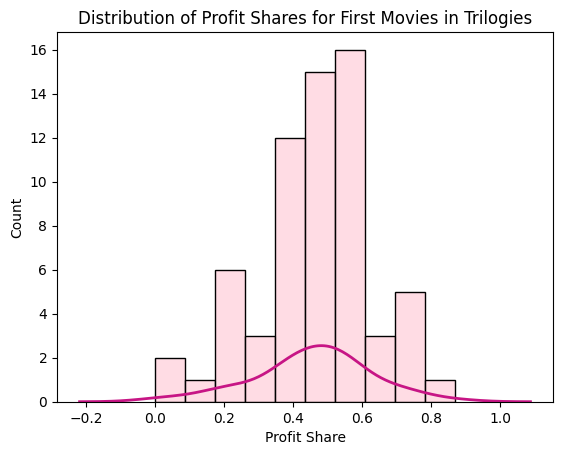

In [19]:
fig, ax = plt.subplots()
sns.histplot(data=df[df['pos'] == 1], x='profit_share', color = '#FFD1DC', ax=ax)
sns.kdeplot(df[df['pos'] == 1]['profit_share'], ax=ax, color='#C71585', linewidth=2, label='Distribution Curve')
plt.title('Distribution of Profit Shares for First Movies in Trilogies')
plt.xlabel('Profit Share')
plt.show()

#### The same for the second movies

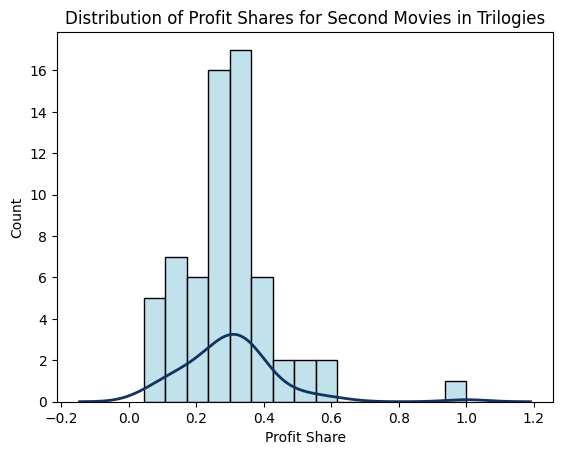

In [20]:
fig, ax = plt.subplots()
sns.histplot(data=df[df['pos'] == 2], x='profit_share', color = '#ADD8E6', ax=ax)
sns.kdeplot(df[df['pos'] == 2]['profit_share'], ax=ax, color='#0F3460', linewidth=2, label='Distribution Curve')
plt.title('Distribution of Profit Shares for Second Movies in Trilogies')
plt.xlabel('Profit Share')
plt.show()

#### And the third ones

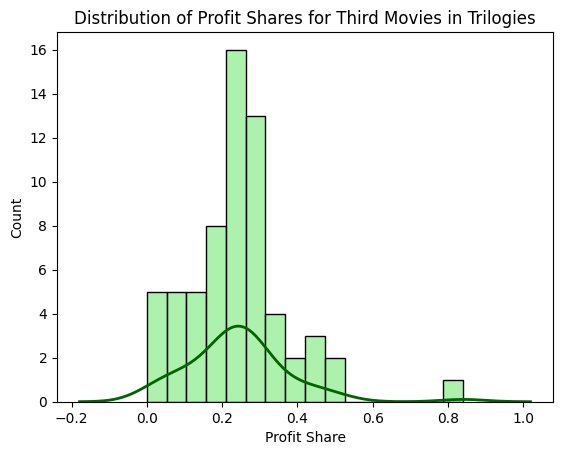

In [21]:
fig, ax = plt.subplots()
sns.histplot(data=df[df['pos'] == 3], x='profit_share', color = '#90EE90', ax=ax)
sns.kdeplot(df[df['pos'] == 3]['profit_share'], ax=ax, color='#006400', linewidth=2, label='Distribution Curve')
plt.title('Distribution of Profit Shares for Third Movies in Trilogies')
plt.xlabel('Profit Share')
plt.show()

#### Distribution Plots for all three movies overlayed upon each other

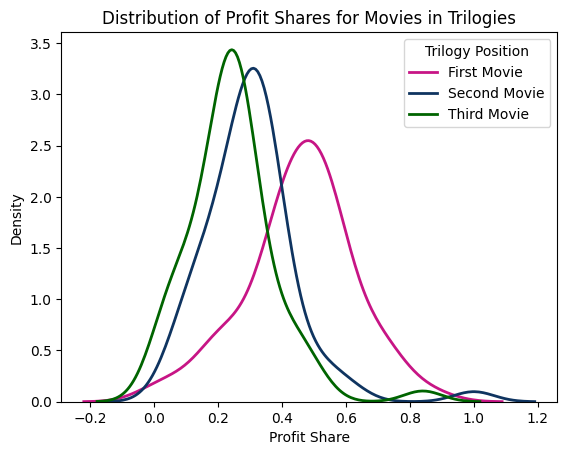

In [22]:
fig, ax = plt.subplots()

# First movie in trilogies
sns.kdeplot(df[df['pos'] == 1]['profit_share'], ax=ax, color='#C71585', linewidth=2, label='First Movie')

# Second movie in trilogies
sns.kdeplot(df[df['pos'] == 2]['profit_share'], ax=ax, color='#0F3460', linewidth=2, label='Second Movie')

# Third movie in trilogies
sns.kdeplot(df[df['pos'] == 3]['profit_share'], ax=ax, color='#006400', linewidth=2, label='Third Movie')

plt.title('Distribution of Profit Shares for Movies in Trilogies')
plt.xlabel('Profit Share')
plt.legend(title='Trilogy Position')
plt.show()


### Ratings share

#### Similarly, the ratings shares of the first movies

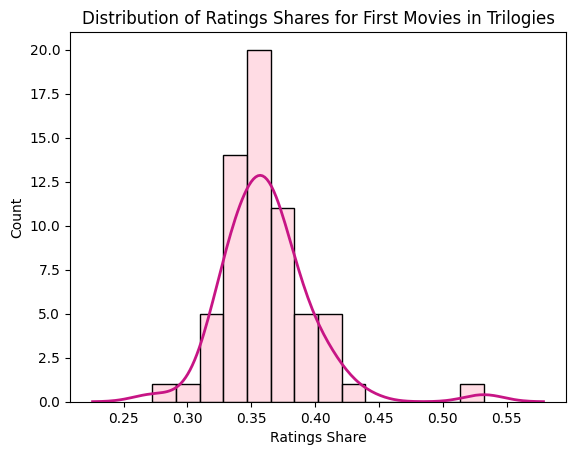

In [23]:
fig, ax = plt.subplots()
sns.histplot(data=df[df['pos'] == 1], x='ratings_share', color = '#FFD1DC', ax=ax)
sns.kdeplot(df[df['pos'] == 1]['ratings_share'], ax=ax, color='#C71585', linewidth=2, label='Distribution Curve')
plt.title('Distribution of Ratings Shares for First Movies in Trilogies')
plt.xlabel('Ratings Share')
plt.show()

#### Second

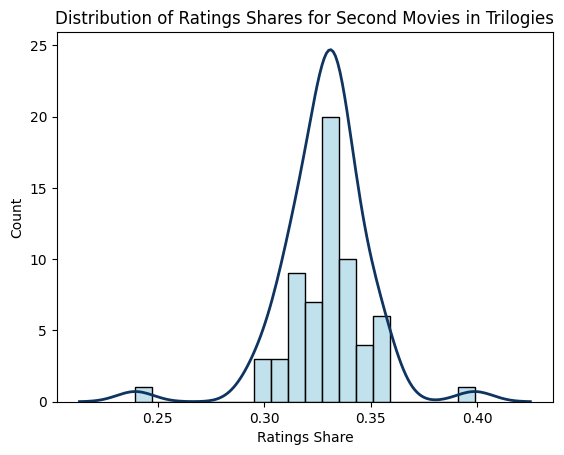

In [24]:
fig, ax = plt.subplots()
sns.histplot(data=df[df['pos'] == 2], x='ratings_share', color = '#ADD8E6', ax=ax)
sns.kdeplot(df[df['pos'] == 2]['ratings_share'], ax=ax, color='#0F3460', linewidth=2, label='Distribution Curve')
plt.title('Distribution of Ratings Shares for Second Movies in Trilogies')
plt.xlabel('Ratings Share')
plt.show()

#### And third

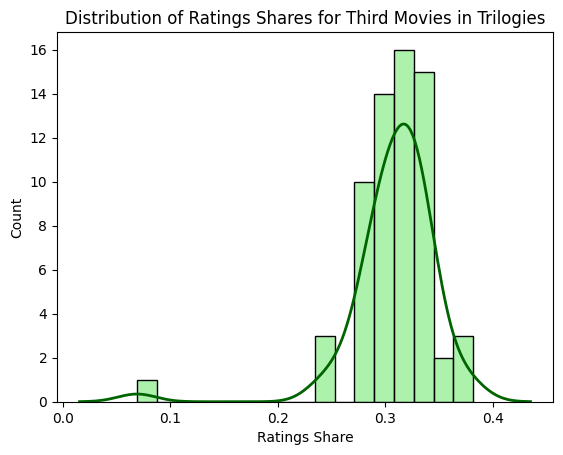

In [25]:
fig, ax = plt.subplots()
sns.histplot(data=df[df['pos'] == 3], x='ratings_share', color = '#90EE90', ax=ax)
sns.kdeplot(df[df['pos'] == 3]['ratings_share'], ax=ax, color='#006400', linewidth=2, label='Distribution Curve')
plt.title('Distribution of Ratings Shares for Third Movies in Trilogies')
plt.xlabel('Ratings Share')
plt.show()

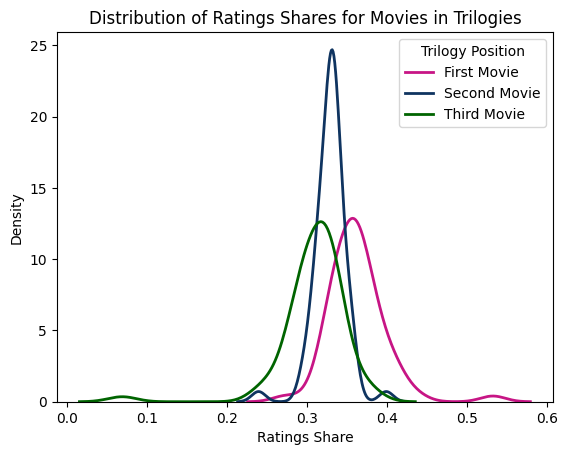

In [26]:
fig, ax = plt.subplots()

# First movie in trilogies
sns.kdeplot(df[df['pos'] == 1]['ratings_share'], ax=ax, color='#C71585', linewidth=2, label='First Movie')

# Second movie in trilogies
sns.kdeplot(df[df['pos'] == 2]['ratings_share'], ax=ax, color='#0F3460', linewidth=2, label='Second Movie')

# Third movie in trilogies
sns.kdeplot(df[df['pos'] == 3]['ratings_share'], ax=ax, color='#006400', linewidth=2, label='Third Movie')

plt.title('Distribution of Ratings Shares for Movies in Trilogies')
plt.xlabel('Ratings Share')
plt.legend(title='Trilogy Position')
plt.show()

## Data Visual Analysis

It is quite clear, as it turns out, that the first movies tend to do better than the second and the third. While the first movie in a series shows better performance in both categories, the difference is more significant in terms of profit share, with a mean of 0.456 while the second and third movies have a mean <= 0.31.  Based off ratings share, the difference performance between the first movie and the others in the series is smaller but still apparent, with the first movie having a mean of 0.362 compared to 0.329 for the second and 0.309 for the third. This goes against our hypothesis, providing evidence that the first movie performs the best in a trilogy rather than the third. As the second movie tends to be similarly underperforming  along with the third, this suggests that our initial reasoning that subsequent movies would generate a greater amount of interest due to the exposure achieved through the first was incorrect, and interest in the first does not necessarily translate to interest in the sequels.

Additionally, an observation in similarity is made apparent through these graphs. This involves the performance of each movie position, which has an order of first, second, and third for both profit shares and rating shares. This suggests that a positive correlation exists between these two categories, with higher profits corresponding to higher ratings. However, this correlation may not be as strong as expected, with the difference in mean between the first and second movie over twice as large as the difference between the second and third movie in terms of profit share but around the same in terms of ratings share. 

### Test for Homogeniety

The Kruskal-Wallis test will be used to compare the distributions of the profits and ratings for the three different positions in the trilogy.

Although there seems to be a visual difference in the distributions, this test will see if there is a statistically significant difference among the distributions.

#### Assumptions:

- Independence: The data we have does not satisify this condition as subsequent movies may be influenced by the success of the prior movie. However, we can still conduct Kruskal-Wallis analysis as it can show us a difference in distributions. We can treat the distributions as independent as our analysis compares performance metrics across different positions within the trilogy. By considering the distributions as independent, our goal is to shed light on how different positions within the trilogy perform relative to each other. We will also use random sampling on each to reduce the dependence.

- Random Sampling: As we do not know if the trilogies collected is sampled randomly or not, we will use random sampling on the data to facilitate the Kruskal-Wallis tests.

- Ordinality: Since both metrics in the dataset are continuous and are categorized into ordered levels or rankings, with higher ratings and profits indicating better performance, we satisfy the condition of having ordinal data.

#### Analysis:

##### With all of the data:

In [27]:
ratings_data = [df[df['pos'] == 1]['ratings_share'], df[df['pos'] == 2]['ratings_share'], df[df['pos'] == 3]['ratings_share']]
profits_data = [df[df['pos'] == 1]['profit_share'], df[df['pos'] == 2]['profit_share'], df[df['pos'] == 3]['profit_share']]

for i in range(2):
    if i == 0:
        metric = "ratings"
        data = ratings_data
    else:
        metric = "profits"
        data = profits_data

    kruskal_result = kruskal(*data)

    print(f"Kruskal-Wallis test for {metric}:")
    print(f"Kruskal-Wallis statistic = {kruskal_result.statistic}")
    print(f"P-value = {kruskal_result.pvalue}")

    if kruskal_result.pvalue < 0.05:
        print(f"There is a statistically significant difference in {metric} among positions in the trilogy.")
    else:
        print(f"There is no statistically significant difference in {metric} among positions in the trilogy.")

Kruskal-Wallis test for ratings:
Kruskal-Wallis statistic = 77.92162200453367
P-value = 1.2009772238924153e-17
There is a statistically significant difference in ratings among positions in the trilogy.
Kruskal-Wallis test for profits:
Kruskal-Wallis statistic = 58.02452032059591
P-value = 2.5126702910597986e-13
There is a statistically significant difference in profits among positions in the trilogy.


##### With random sampling:

In [28]:
for i in range(2):
    if i == 0:
        metric = "ratings"
        data = ratings_data
    else:
        metric = "profits"
        data = profits_data
    
    kruskal_results = []
    p_values = []

    for _ in range(100):
        data = [np.random.choice(data[0], size=30, replace=False),np.random.choice(data[1], size=30, replace=False),np.random.choice(data[2], size=30, replace=False)]

        kruskal_result = kruskal(*data)
        kruskal_results.append(kruskal_result)
        p_values.append(kruskal_result.pvalue)


    if (sum(p_values)/len(p_values)) < 0.05:
        print(f"Given a mean of the p-values of {(sum(p_values)/len(p_values))}. There is a statistically significant difference in {metric} among positions in the trilogy.")
    else:
        print(f"Given a mean of the p-values of {(sum(p_values)/len(p_values))}. There is no statistically significant difference in {metric} among positions in the trilogy.")

Given a mean of the p-values of 2.081690630850298e-09. There is a statistically significant difference in ratings among positions in the trilogy.
Given a mean of the p-values of 2.9784443519717906e-08. There is a statistically significant difference in profits among positions in the trilogy.


#### Results:

After performing the Kruskal-Wallis test and Kruskal Wallis on 100 random samples of the data, the p-values for both the ratings share and profits share were below 0.05, we can conclude that there was a statistically significant difference in profits and ratings among the positions in the trilogy. This shows that the visual difference that was observed is valid.

##### Limitations
This test may be flawed as the independence criterion is not fully met. Further analysis may be conducted to reduce the dependence. However with the way that this data is collected and given that our data is meant to be relative to trilogies, our conclusions can be viewed as valid.

## EDA: Fitting the data to a classifier

We opted to use a classifier with the polynomial kernel of degree 2. We figured it was appropriate since we wish to predict the position of a movie from 2 independent variables. Splitting the data to 80% training and 20% testing is an arbitrary decision.

#### Training the classifier and testing it on the test set

In [29]:
ML_X = df[['profit_share','ratings_share']]
ML_Y = df[['pos']]

ML_training = int(df.shape[0]*0.75)

ML_train_X = ML_X[:ML_training]
ML_train_Y = ML_Y[:ML_training]
ML_test_X = ML_X[ML_training:]
ML_test_Y = ML_Y[ML_training:]

def train_SVM(X, y, kernel='poly', degree=2):
    clf = SVC(kernel=kernel, degree=degree)
    clf.fit(X, y)
    return clf

pd_clf = train_SVM(ML_train_X, ML_train_Y.values.ravel())
predicted_train_Y = pd_clf.predict(ML_train_X)
predicted_test_Y = pd_clf.predict(ML_test_X)

#### Checking out the training performance

In [30]:
class_report_train = classification_report(ML_train_Y, predicted_train_Y)
print(class_report_train)

              precision    recall  f1-score   support

           1       0.88      0.75      0.81        48
           2       0.50      0.69      0.58        48
           3       0.70      0.54      0.61        48

    accuracy                           0.66       144
   macro avg       0.69      0.66      0.67       144
weighted avg       0.69      0.66      0.67       144



#### Checking out the testing performance

In [31]:
class_report_test = classification_report(ML_test_Y, predicted_test_Y)
print(class_report_test)

              precision    recall  f1-score   support

           1       0.60      0.56      0.58        16
           2       0.47      0.56      0.51        16
           3       0.50      0.44      0.47        16

    accuracy                           0.52        48
   macro avg       0.52      0.52      0.52        48
weighted avg       0.52      0.52      0.52        48



## Result Analysis

As we can see, the classifier does surprisingly well in predicting if the movie is the first one in a trilogy. However, it looks like it's failing on the second and third movies. Let's take a look at the confusion matrix.

In [32]:
conf_mat_test = confusion_matrix(ML_test_Y, predicted_test_Y)
print(conf_mat_test)

[[9 5 2]
 [2 9 5]
 [4 5 7]]


That confusion matrix shows that the classifier tends to get confused whether a movie is the second or the third, if it chooses between those two. This behavior can be explained by just taking a look at the histograms above. The second and third movies performances are almost indistinguishable. Let's try another approach: classify whether a movie is the first one in a trilogy or not.

## A Different Approach

#### Changing the position of the movies to whether or not a movie is the first one in the trilogy

In [33]:
def change_pos(x):
    if x == 1:
        return 1
    return 0 

df['pos'] = df['pos'].apply(change_pos)
df.head()

,profit_share,ratings_share,pos
0,0.480113,0.368210,1
1,0.375429,0.356727,0
2,0.144459,0.275063,0
3,0.365004,0.363692,1
4,0.358080,0.316409,0


#### Doing the same thing as above

In [34]:
ML_X = df[['profit_share','ratings_share']]
ML_Y = df[['pos']]

ML_training = int(df.shape[0]*0.75)

ML_train_X = ML_X[:ML_training]
ML_train_Y = ML_Y[:ML_training]
ML_test_X = ML_X[ML_training:]
ML_test_Y = ML_Y[ML_training:]

def train_SVM(X, y, kernel='poly', degree = 2):
    clf = SVC(kernel=kernel, degree=degree)
    clf.fit(X, y)
    
    return clf

pd_clf = train_SVM(ML_train_X, ML_train_Y.values.ravel())
predicted_train_Y = pd_clf.predict(ML_train_X)
predicted_test_Y = pd_clf.predict(ML_test_X)

In [35]:
class_report_train = classification_report(ML_train_Y, predicted_train_Y)
print(class_report_train)

              precision    recall  f1-score   support

           0       0.86      0.97      0.91        96
           1       0.92      0.69      0.79        48

    accuracy                           0.88       144
   macro avg       0.89      0.83      0.85       144
weighted avg       0.88      0.88      0.87       144



In [36]:
class_report_test = classification_report(ML_test_Y, predicted_test_Y)
print(class_report_test)

              precision    recall  f1-score   support

           0       0.76      0.81      0.79        32
           1       0.57      0.50      0.53        16

    accuracy                           0.71        48
   macro avg       0.67      0.66      0.66        48
weighted avg       0.70      0.71      0.70        48



Now, the performance is noticeably better.

# Ethics & Privacy

Considering the nature of our research question, it is clear that ethics is generally not a primary concern. These datasets are publicly available. While this does not necessarily mean that ethics shouldn't be looked at, it could indicate that most people believe this is ethically fine. Now, moving onto the subject of privacy. The dataset we're working with are mostly general statistics of performance of movies. This means that the numbers are essentially not associated with anyone. What this means is that given a review of a movie that is included in this research, the person who contributed to that rating will not be identifiable within this dataset we're using. However, that might not be the case when looking at the source of the dataset. We're using popular movie review sites like IMDb, Rotten Tomatoes, etc, each of which have their own privacy policies. Even then, the user consented to those policies by using the site, implicitly agreeing to the terms of service.

# Discussion and Conclusion

Prior to this exploration, much of the discussion surrounding movie trilogies have been informal, with articles primarily sharing opinions about how well a movie in a trilogy was relative to others in the series. Our paper contributes to the discussion through the scientific analysis of the performance of each movie in a trilogy, with performance measured by budget, revenue, voting average, voting count, and popularity. This presents a more formal way method of comparison that could supplement previous opinion articles done on this topic. The results are also of interest to those involved in filmmaking, both in making a decision on whether to add a new installment to a movie series as well as which factors should be given more focus in order to increase the film’s success.

Our hypothesis was initially based on three key points regarding the third installment, namely that they typically have the highest budget in their series, can gain more exposure due to the release of the previous movies, and can also build more anticipation through the plots of the previous. While the latter two are assumptions that we did not attempt to quantify in this analysis, the first was reflected in our inclusion of budget in evaluating a movie’s performance. 

Through our analysis, we fail to support our hypothesis that the last movie performs the best in trilogies. While the third movie may often have the highest budget in a series, after accounting for its revenue relative to its budget, we found that the first movie significantly outperformed it. Similar results were found for ratings, with the first movie also having a significantly higher average mean for its ratings compared to the second and third. This suggests that budget is not as strong a factors as initially assumed, and there are other factors that play into the audience’s reception of the movie and their willingness to spend.

Though the disparities are made clear through the data visualizations, we decided to test the significance of these differences further by fitting the data to a classifier, using profit share and ratings share as our two independent variables that the prediction would be based on. We found that the classifier was more precise at predicting which movie is the first in its series. When we changed the classifier to predict whether an installment is the first movie rather than predict its position in the series, accuracy and precision greatly increased, further supporting the idea that the first movie significantly outperforms others in its series.

Regarding the data we worked with, there are several limitations to consider in answering this question. Ideally, we would be able to collect the opinions of all who watched a movie in a particular series, as well as other information on the audience such as whether they watched any of the previous movies in the series. While we considered webscraping in order to collect a larger and more varied sample of reviews, we ultimately decided to utilize the MovieLens dataset, which is limited to users who posted in MovieLens. This could result in less representative data of all who watched the movie, with reviews only pulled from a single site. 

While providing an extensive amount of reviews that are updated over time, demographic information is also lost. This limits our ability to analyze our latter assumptions regarding our hypothesis. However, we found this was a beneficial tradeoff when considering ethics, with increased privacy for those who submitted a review. This served as a useful reminder of balancing ideal data with ethics, and considering whether the former should be collected or analyzed in addition to whether it is possible.

In summation, our analysis explored the relative performance between each movie in a trilogy. Going against our initial inferences, we are not able to support our hypothesis, with our analysis instead providing more support for the first movie as the best installment in a series. In our project, we decided to study movies with no restriction in release date, which could result in findings less relevant to modern movies. This prompts the question, does restricting the timeframe affect the result? Additional confounding factors could also be considered, such as a quantification of anticipation for each movie. Our investigation serves as an invitation for further analysis regarding movie trilogies.

# Team Contributions

- Vaibhav Bommisetty - Data Wrangling, cleaning and Visualization, statistics, video
- Daniel Erskine - Dataset acquisition, research, writing for background & prior work, ideas
- Angie Nguyen - Data wrangling, writing for data analysis and conclusion, video
- Jett Ou - Machine learning implementation, abstract, final video composition/editing
- Dan Van - Data wrangling, statistics, writing for ethics & privacy, EDA, and datasets, ideas, leadership and organization 
